Data Loading and Preparation

Load the diabetes dataset. For simplicity, we only keep a single feature in the data. Then, we split the data and target into training and test sets.

In [11]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

Linear regression model

We create a linear regression model and fit it on the training data. Note that by default, an intercept is added to the model. We can control this behavior by setting the fit_intercept parameter.

In [12]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

Model evaluation

We evaluate the model’s performance on the test set using the mean squared error and the coefficient of determination.

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 2548.07
Coefficient of determination: 0.47


#Plotting the results

Finally, we visualize the results on the train and test data.

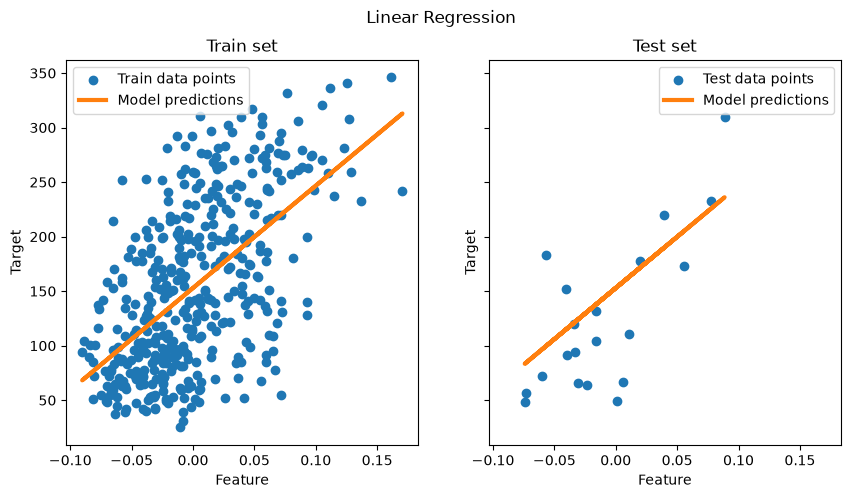

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()

OLS on this single-feature subset learns a linear function that minimizes the mean squared error on the training data. We can see how well (or poorly) it generalizes by looking at the R^2 score and mean squared error on the test set. In higher dimensions, pure OLS often overfits, especially if the data is noisy. Regularization techniques (like Ridge or Lasso) can help reduce that.

Ordinary Least Squares and Ridge Regression Variance

Next, we illustrate the problem of high variance more clearly by using a tiny synthetic dataset. We sample only two data points, then repeatedly add small Gaussian noise to them and refit both OLS and Ridge. We plot each new line to see how much OLS can jump around, whereas Ridge remains more stable thanks to its penalty term.

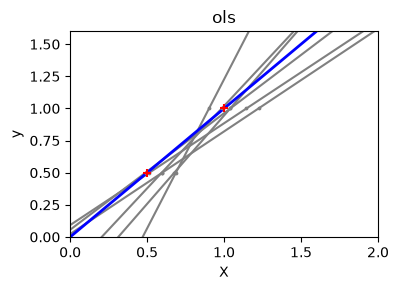

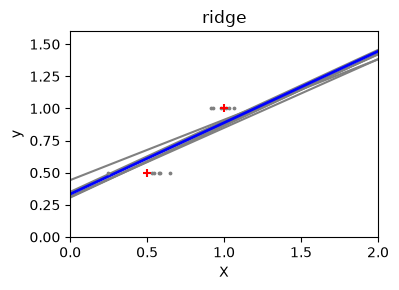

In [15]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

X_train = np.c_[0.5, 1].T
y_train = [0.5, 1]
X_test = np.c_[0, 2].T

np.random.seed(0)

classifiers = dict(
    ols=linear_model.LinearRegression(), ridge=linear_model.Ridge(alpha=0.1)
)

for name, clf in classifiers.items():
    fig, ax = plt.subplots(figsize=(4, 3))

    for _ in range(6):
        this_X = 0.1 * np.random.normal(size=(2, 1)) + X_train
        clf.fit(this_X, y_train)

        ax.plot(X_test, clf.predict(X_test), color="gray")
        ax.scatter(this_X, y_train, s=3, c="gray", marker="o", zorder=10)

    clf.fit(X_train, y_train)
    ax.plot(X_test, clf.predict(X_test), linewidth=2, color="blue")
    ax.scatter(X_train, y_train, s=30, c="red", marker="+", zorder=10)

    ax.set_title(name)
    ax.set_xlim(0, 2)
    ax.set_ylim((0, 1.6))
    ax.set_xlabel("X")
    ax.set_ylabel("y")

    fig.tight_layout()

plt.show()

Exercices de régression linéaire simple et multiple

On refait la même analyse mais cette fois-ci avec une base de données csv. On télécharge en premier lieu notre fichier et on le met dans notre drive.
Régression Simple : Modélise la relation entre une variable indépendante et une variable dépendante.
Exemple : Prédire le prix d'une maison en fonction de sa superficie.

In [16]:
import pandas as pd

database = pd.read_csv("house_data.csv")